# Milestone 5

## Detection of Hydroxychloroquine Macular Toxicity via OCT Images

Proyecto Integrador - TC5035.10

Team 45

Tecnológico de Monterrey

Sponsor: Dr. Alejandro Rodríguez García, Hospital Zambrano Hellion

Date: May 2026

Team members:

- Natalia Nevarez Tinoco - A01566204
- Alejandro Caamaño Granados - A00843392
- Diana Jimena López Nájera - A01024913

This notebook builds on Milestone 4 and reuses its infrastructure (the Google Drive layout, the HCQuery feature extractor, the patient-grouped cross-validation protocol, and the metric / threshold / bootstrap helpers). It adds the ensemble layer required by Milestone 5 and incorporates the tutor's recommendations from the June 2nd sessions.

### Tutor's recommendations incorporated in this milestone

- **Train two additional networks on our data**

The tutor suggested trying **VGG16** and **MobileNetV2** because both use small convolutional filters (3x3 and 1x1), well suited to detecting the small, highly localized changes in our images (the central "flying saucer" type region). EfficientNet-B4 (the HCQuery backbone) already uses 3x3 and 5x5 kernels; these two networks complement that receptive-field range. VGG16 is a larger network (slower training); MobileNetV2 is light and fast.

- **Ensemble by voting over the trained networks**

Inference is run with the three deep networkds and they are combined by **hard voting** and **soft voting**. Soft voting is the indicated choice when the classes are visually very similar (our case). Voting types cannot be mixed within a single ensemble.

- **Target of four ensembles** (Three acceptable if compute runs short, with justification and the option to drop a "noisy" model).

### Two methodological improvements over Milestone 4 (flagged in M4 Section 9.1)

1. A held-out test set is separated **before** everything else. All model building, tuning, and threshold selection happen on the development set; the test set is used only once, at the end.
2. Stacking is built leakage-free: every base prediction the meta-model receives is *out-of-fold*, generated with patient-grouped CV, so no patient appears at once in the training and in the prediction of the same base model.

## 0. Google Drive setup

Same layout as Milestone 4. It reads the same processed-image export (`OCT_Dataset_Limpio_cropped`) and the same `hcquery_model.pt` checkpoint.

In [1]:
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')

EXPECTED = ('/content/drive/MyDrive/Colab Notebooks/MNA/'
            'Proyecto Integrador/Avance5/OCT_Dataset_Limpio_cropped')

data_root = None
if Path(EXPECTED).exists():
    data_root = Path(EXPECTED)
else:
    matches = []
    for root, dirs, files in os.walk('/content/drive/MyDrive', followlinks=True):
        if Path(root).name == 'OCT_Dataset_Limpio_cropped':
            dirs_low = [d.lower() for d in dirs]
            if 'no' in dirs_low and 'si' in dirs_low:
                matches.append(Path(root))
    for m in matches:
        if 'Avance3' in str(m):
            data_root = m
            break
    if data_root is None and matches:
        data_root = matches[0]

if data_root is not None:
    actual = {d.lower(): d for d in os.listdir(data_root)}
    NO_DIR = data_root / actual['no']
    SI_DIR = data_root / actual['si']
    print(f'Processed dataset found at: {data_root}')
    print(f'  No: {len(list(NO_DIR.iterdir()))} files')
    print(f'  Si: {len(list(SI_DIR.iterdir()))} files')
else:
    print('ERROR: dataset not found.')

HCQUERY_MODEL_PATH = ('/content/drive/MyDrive/Colab Notebooks/MNA/'
                     'Proyecto Integrador/Avance5/hcquery_model.pt')

if Path(HCQUERY_MODEL_PATH).exists():
    print(f'HCQuery model found: {HCQUERY_MODEL_PATH}')
    HCQ_AVAILABLE = True
else:
    print(f'ERROR: HCQuery model not found at {HCQUERY_MODEL_PATH}')
    HCQ_AVAILABLE = False

Mounted at /content/drive
Processed dataset found at: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance5/OCT_Dataset_Limpio_cropped
  No: 179 files
  Si: 15 files
HCQuery model found: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance5/hcquery_model.pt


## 1. Import Libraries

Milestone 5 adds the ensemble estimators (`RandomForestClassifier`, `HistGradientBoostingClassifier`), `cross_val_predict` for leakage-free out-of-fold predictions, `permutation_importance`, and the `vgg16` and `mobilenet_v2` networks from `torchvision`. Everything else mirrors Milestone 4.

In [2]:
import glob, random, warnings, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
    recall_score, precision_score, fbeta_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as tv_models

try:
    import optuna
    print('optuna already installed.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    print('optuna installed.')

try:
    from efficientnet_pytorch import EfficientNet
    print('efficientnet_pytorch already installed.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'efficientnet_pytorch', '-q'])
    from efficientnet_pytorch import EfficientNet
    print('efficientnet_pytorch installed.')

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries imported. Compute device: {DEVICE}')

optuna installed.
efficientnet_pytorch installed.
Libraries imported. Compute device: cuda


### 1.1 Compute Parameters

Training these deep networks with grouped CV (out-of-fold) plus the final refits is the expensive part of the network. On GPU it is several minutes per network per fold. If time runs short, the tutor authorized dropping to three models; lowering `N_SPLITS` or the epochs speeds things up at the cost of wider confidence intervals. Make sure the Colab runtime is set to **GPU**.

In [3]:
N_SPLITS = 5

# Per-network fine-tune settings (image size, lf, weight decay, epochs, patience)
CNN_CFG = {
    'EfficientNet/M6': dict(img=256, lr=1e-5, wd=1e-3, epochs=15, patience=4),  # M4 best
    'VGG16':           dict(img=224, lr=1e-5, wd=1e-3, epochs=12, patience=4),  # partial FT
    'MobileNetV2':     dict(img=224, lr=1e-4, wd=1e-4, epochs=15, patience=4),  # full FT
}

print('Compute config set. GPU strongly recommended.')

Compute config set. GPU strongly recommended.


## 2. Data loading and held-out test set

Same parser and same patient grouping as Milestone 4. The held-out split is now built **manually at the patient level** to fix a problem in the earlier run: with so few Si-bearing patients, `StratifiedGroupKFold` could not stratify (the grouping constraint overrode it) and left **zero Si cases in the test fold**, making the held-out evaluation vacuous. We now hold out ~20% of *each* class and force at least two Si patients into the test fold, so the test set always contains toxicity cases. Grouping still guarantees that no patient's images cross the train/test line.

Given only ~15 Si images, **development out-of-fold (OOF) cross-validation is the primary evaluation**, it is what the comparison table and the final-model choice are based on, and it is the same protocol Milestone 4 relied on. The forced-Si held-out test is reported as a **secondary, supporting check** (objective 3.6): with only a handful of Si cases its metrics carry very wide confidence intervals and are read as directional, not definitive.

In [4]:
def parse_patient_id(filepath):
    stem = Path(filepath).stem
    parts = stem.split('_')
    if stem.startswith('AUTO') and len(parts) > 1:
        return parts[1]
    return parts[0]

records = []
for label_dir, label in [(NO_DIR, 'no'), (SI_DIR, 'si')]:
    for fp in label_dir.iterdir():
        if fp.suffix.lower() in ('.png', '.jpg', '.jpeg'):
            records.append({'filepath': str(fp), 'label': label,
                            'label_enc': 0 if label == 'no' else 1,
                            'patient_id': parse_patient_id(fp)})

df = pd.DataFrame(records).reset_index(drop=True)
print(f'Total processed images: {len(df)}')
print(df['label'].value_counts().rename('count'))
print(f'Unique patients: {df["patient_id"].nunique()}')

y_all = df['label_enc'].values
groups_all = df['patient_id'].values

# --- FIX: force Si patients into the held-out test fold ---
# The earlier StratifiedGroupKFold split left 0 Si cases in the test fold: with so few
# Si-bearing patients the group constraint overrides stratification. We build the test
# split manually at the patient level, holding out ~20% of EACH class and at least two
# Si patients, so the held-out test always contains toxicity cases.
patient_label = df.groupby('patient_id')['label_enc'].max()   # patient = Si if any Si image
si_patients = patient_label[patient_label == 1].index.to_numpy()
no_patients = patient_label[patient_label == 0].index.to_numpy()

rng = np.random.RandomState(RANDOM_STATE)
rng.shuffle(si_patients); rng.shuffle(no_patients)

n_si_test = max(2, int(round(0.20 * len(si_patients))))
n_no_test = int(round(0.20 * len(no_patients)))
test_patients = set(si_patients[:n_si_test]) | set(no_patients[:n_no_test])

test_mask = df['patient_id'].isin(test_patients).values
test_idx = np.where(test_mask)[0]
dev_idx  = np.where(~test_mask)[0]

df_dev = df.iloc[dev_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
y_dev = df_dev['label_enc'].values
y_test = df_test['label_enc'].values
groups_dev = df_dev['patient_id'].values

# Patient-grouped CV used for ALL development work (OOF, tuning, thresholds)
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'\nSi-bearing patients: {len(si_patients)} | No-only patients: {len(no_patients)}')
print('--- Split summary ---')
print(f'Development: {len(df_dev)} imgs | Si={int(y_dev.sum())} No={int((y_dev==0).sum())} '
      f'| patients={df_dev["patient_id"].nunique()}')
print(f'Held-out test: {len(df_test)} imgs | Si={int(y_test.sum())} No={int((y_test==0).sum())} '
      f'| patients={df_test["patient_id"].nunique()}')
assert set(df_dev['patient_id']).isdisjoint(set(df_test['patient_id'])), 'Patient leakage!'
assert int(y_test.sum()) >= 1, 'Test fold still has no Si cases!'
assert int(y_dev.sum()) >= N_SPLITS, 'Too few Si in dev for grouped CV!'
print('Checks passed: patient-disjoint and Si present in the test fold.')

Total processed images: 194
label
no    179
si     15
Name: count, dtype: int64
Unique patients: 69

Si-bearing patients: 5 | No-only patients: 64
--- Split summary ---
Development: 153 imgs | Si=11 No=142 | patients=54
Held-out test: 41 imgs | Si=4 No=37 | patients=15
Checks passed: patient-disjoint and Si present in the test fold.


In [5]:
# How many Si images does each Si patient have?
si_counts = (df[df['label_enc'] == 1]
             .groupby('patient_id').size()
             .sort_values(ascending=False))
print("Si images per Si patient (most -> fewest):")
for pid, n in si_counts.items():
    print(f"  patient {pid}: {n} Si image(s)")
print(f"\nSi patients: {len(si_counts)}  |  Si images: {int(si_counts.sum())}")

Si images per Si patient (most -> fewest):
  patient MONICA EUGENIA: 7 Si image(s)
  patient CATALINA: 2 Si image(s)
  patient MARIA ALEJANDRA: 2 Si image(s)
  patient NORMA-MIRYAM: 2 Si image(s)
  patient ROCIO DEL CARMEN: 2 Si image(s)

Si patients: 5  |  Si images: 15


## 3. Milestone 5 strategy

### 3.1 Individual models (voters)

Three deep networks trained on our data, plus the best classical classifier from Milestone 4:

| Model | Type | Filters / rationale |
|---|---|---|
| **EfficientNet-B4 (M6, HCQuery)** | Deep network (full fine-tune) | Best individual from Milestone 4; 3×3 and 5×5 kernels |
| **VGG16** | Deep network (partial fine-tune) | Large network; 3×3 kernels, good for direction changes |
| **MobileNetV2** | Deep network (full fine-tune) | Light network; 3×3 and 1×1 kernels, fast to train |
| **HCQuery + SVM (RBF)** | Classical | Best classical head from Milestone 4 |

### 3.2 The five ensembles

| Ensemble | Strategy | Mechanism |
|---|---|---|
| **E1 — Random forest** | Homogeneous | Bagging of trees over HCQuery features (1792-d) |
| **E2 — Gradient boosting** | Homogeneous | Boosting of trees over HCQuery features |
| **E3 — Soft voting** | Heterogeneous | Average of the 3 networks' probabilities |
| **E4 — Hard voting** | Heterogeneous | Majority vote of the 3 networks |
| **E5 — Stacking** | Heterogeneous | Meta-model (LogReg) over the OOF predictions of the 3 networks + SVM |

### 3.3 Hard vs soft (tutor's recommendation)

- **Hard voting:** each network casts a class vote (Si/No) using its own F2-optimal threshold; the majority wins. "Democracy" style.
- **Soft voting:** the three networks' probabilities are averaged and the decision is made on that average. It is the right choice when the classes look very similar, because it preserves each model's confidence instead of discarding it.
- They are not mixed: an ensemble is all-hard or all-soft.

### 3.4 Evaluation protocol

- **Primary metric: PR-AUC** (average precision on Si), threshold-independent and robust to the 12:1 imbalance.
- **Secondary:** F2-Si (weights recall) and Si-recall (clinical metric).
- **Threshold:** swept over the development OOF predictions to the F2-optimal point; locked and applied unchanged to the test set.
- **Honest expectation:** with 15 Si images, an ensemble is unlikely to beat M6 outside its confidence interval. The value of Milestone 5 is the rigorous, leakage-free comparison plus the first evaluation on unseen data, not a manufactured win.

## 4. HCQuery feature extraction (1792-d)

Identical extractor to Milestone 4. It is computed once for the full dataset and indexed into development and test. These features feed the two tree ensembles (E1, E2) and the classical SVM classifier.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_eval_transform(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

class OCTDatasetRGB(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['filepath']).convert('RGB')
        return self.transform(img), torch.tensor(row['label_enc'], dtype=torch.float32)

assert HCQ_AVAILABLE, 'hcquery_model.pt not found. Update HCQUERY_MODEL_PATH.'
IMG_SIZE_HCQ = 256

raw_sd = torch.load(HCQUERY_MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict_hcq = {k.partition('module.')[2]: v for k, v in raw_sd.items()}

hcq_full = EfficientNet.from_name('efficientnet-b4')
hcq_full._fc = nn.Linear(hcq_full._fc.in_features, 2)
hcq_full.load_state_dict(state_dict_hcq)
hcq_full.to(DEVICE).eval()
print(f'HCQuery loaded. Parameters: {sum(p.numel() for p in hcq_full.parameters()):,}')

eval_tf_hcq = make_eval_transform(IMG_SIZE_HCQ)
loader = DataLoader(OCTDatasetRGB(df, eval_tf_hcq), batch_size=16, shuffle=False)

hcq_features = []
with torch.no_grad():
    for x, _ in loader:
        x = x.to(DEVICE)
        feats = hcq_full.extract_features(x)
        feats = hcq_full._avg_pooling(feats).flatten(start_dim=1)
        hcq_features.append(feats.cpu().numpy())

X_hcq_all = np.vstack(hcq_features)
X_hcq_dev = X_hcq_all[dev_idx]
X_hcq_test = X_hcq_all[test_idx]
print(f'HCQuery features: all={X_hcq_all.shape}  dev={X_hcq_dev.shape}  test={X_hcq_test.shape}')

HCQuery loaded. Parameters: 17,552,202
HCQuery features: all=(194, 1792)  dev=(153, 1792)  test=(41, 1792)


## 5. Shared helpers (metrics, fine-tune CV, threshold, bootstrap)


In [7]:
def metrics_from_oof(name, y_true, y_pred, y_score, train_time, n_params=None):
    return {
        'model': name,
        'accuracy': (y_pred == y_true).mean(),
        'recall_Si': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'prec_Si': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f2_Si': fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_score),
        'train_time_s': train_time,
        'n_params': n_params,
    }

def oof_proba_classical(build_pipeline_fn, X, y, groups, cv):
    '''Leakage-safe out-of-fold probabilities for a sklearn pipeline factory.'''
    oof_score = np.zeros(len(y), dtype=float)
    t0 = time.time()
    for tr, va in cv.split(X, y, groups):
        pipe = build_pipeline_fn()
        pipe.fit(X[tr], y[tr])
        oof_score[va] = pipe.predict_proba(X[va])[:, 1]
    return oof_score, time.time() - t0

def sweep_threshold(y_true, y_score, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for t in thresholds:
        pred = (y_score >= t).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        tn = int(((pred == 0) & (y_true == 0)).sum())
        sens = tp / max(tp + fn, 1)
        spec = tn / max(tn + fp, 1)
        prec = tp / max(tp + fp, 1)
        f2 = fbeta_score(y_true, pred, beta=2, pos_label=1, zero_division=0)
        rows.append({'threshold': t, 'f2': f2, 'recall': sens,
                     'specificity': spec, 'precision': prec})
    return pd.DataFrame(rows)

def best_f2_threshold(y_true, y_score):
    s = sweep_threshold(y_true, y_score)
    return float(s.loc[s['f2'].idxmax(), 'threshold'])

def bootstrap_ci(y_true, y_score, n_boot=1000, alpha=0.05):
    rng = np.random.RandomState(RANDOM_STATE)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    boot = []
    for _ in range(n_boot):
        ps = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        ns = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        idx = np.concatenate([ps, ns])
        try:
            boot.append(average_precision_score(y_true[idx], y_score[idx]))
        except ValueError:
            continue
    return float(np.mean(boot)), float(np.percentile(boot, 100*alpha/2)), \
           float(np.percentile(boot, 100*(1-alpha/2)))

print('Helpers ready.')

Helpers ready.


## 6. Deep-Network training infrastructure

The training loop (`train_cnn`) is architecture-agnostic; it takes a model that emits 1 logit and the loaders. It mirrors the M4 decisions (no `pos_weight`, the balanced sampler handles imbalance, early stopping on validation loss). The three network builders differ only in which layers are unfrozen.

In [8]:
class RandomGaussianNoise(nn.Module):
    def __init__(self, a=0.01, b=0.03): super().__init__(); self.a, self.b = a, b
    def forward(self, t):
        std = torch.empty(1).uniform_(self.a, self.b).item()
        return torch.clamp(t + torch.randn_like(t)*std, 0., 1.)

def make_train_transform(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(10),
        transforms.RandomAffine(0, translate=(0.06,0.06), scale=(0.92,1.08), shear=4),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(), RandomGaussianNoise(0.01,0.03),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def make_balanced_sampler(frame):
    labels = frame['label_enc'].values
    cw = 1.0/np.maximum(np.bincount(labels, minlength=2), 1)
    return torch.utils.data.WeightedRandomSampler(
        torch.as_tensor(cw[labels], dtype=torch.double), len(labels), replacement=True)

def train_cnn(model, tr_loader, va_loader, epochs, lr, weight_decay, patience):
    crit = nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                           lr=lr, weight_decay=weight_decay)
    best, best_state, no_imp = float('inf'), None, 0
    for ep in range(epochs):
        model.train()
        for x, yb in tr_loader:
            x, yb = x.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(x).squeeze(1), yb); loss.backward(); opt.step()
        model.eval(); vr = 0.
        with torch.no_grad():
            for x, yb in va_loader:
                x, yb = x.to(DEVICE), yb.to(DEVICE)
                vr += crit(model(x).squeeze(1), yb).item()*x.size(0)
        vl = vr/len(va_loader.dataset)
        if vl < best - 1e-4: best, best_state, no_imp = vl, copy.deepcopy(model.state_dict()), 0
        else:
            no_imp += 1
            if no_imp >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model

def predict_scores(model, loader):
    model.eval(); s = []
    with torch.no_grad():
        for x, _ in loader:
            s += torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu().tolist()
    return np.array(s)

# Network builders (each returns a model emitting 1 logit)
def build_efficientnet():
    m = EfficientNet.from_name('efficientnet-b4')
    m._fc = nn.Linear(m._fc.in_features, 2); m.load_state_dict(state_dict_hcq)
    inf = m._fc.in_features
    m._fc = nn.Sequential(nn.Linear(inf,128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128,1))
    for p in m.parameters(): p.requires_grad = True       # full fine-tune
    return m.to(DEVICE)

def build_vgg16():
    m = tv_models.vgg16(weights=tv_models.VGG16_Weights.IMAGENET1K_V1)
    for p in m.features.parameters(): p.requires_grad = False
    for p in m.features[24:].parameters(): p.requires_grad = True   # unfreeze last conv block
    m.classifier[6] = nn.Linear(4096, 1)
    for p in m.classifier.parameters(): p.requires_grad = True
    return m.to(DEVICE)

def build_mobilenetv2():
    m = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
    inf = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(inf, 1))
    for p in m.parameters(): p.requires_grad = True       # full fine-tune (small net)
    return m.to(DEVICE)

CNN_BUILDERS = {'EfficientNet/M6': build_efficientnet,
                'VGG16': build_vgg16, 'MobileNetV2': build_mobilenetv2}

def cnn_oof_scores(name, frame, y_arr, groups_arr, cv):
    cfg = CNN_CFG[name]; build_fn = CNN_BUILDERS[name]
    tr_tf = make_train_transform(cfg['img']); ev_tf = make_eval_transform(cfg['img'])
    oof = np.zeros(len(frame)); t0 = time.time()
    for k, (tr, va) in enumerate(cv.split(frame, y_arr, groups_arr)):
        trf = frame.iloc[tr].reset_index(drop=True); vaf = frame.iloc[va].reset_index(drop=True)
        trl = DataLoader(OCTDatasetRGB(trf, tr_tf), batch_size=16, sampler=make_balanced_sampler(trf))
        val = DataLoader(OCTDatasetRGB(vaf, ev_tf), batch_size=16, shuffle=False)
        model = train_cnn(build_fn(), trl, val, cfg['epochs'], cfg['lr'], cfg['wd'], cfg['patience'])
        oof[va] = predict_scores(model, val)
        print(f'  [{name}] fold {k} done')
    return oof, time.time() - t0

def cnn_fit_predict(name, train_frame, predict_frame, val_frac=0.15):
    cfg = CNN_CFG[name]; build_fn = CNN_BUILDERS[name]
    tr_tf = make_train_transform(cfg['img']); ev_tf = make_eval_transform(cfg['img'])
    inner = StratifiedGroupKFold(n_splits=max(2, int(round(1/val_frac))), shuffle=True, random_state=RANDOM_STATE)
    tr, va = next(inner.split(train_frame, train_frame['label_enc'].values, train_frame['patient_id'].values))
    trf = train_frame.iloc[tr].reset_index(drop=True); vaf = train_frame.iloc[va].reset_index(drop=True)
    trl = DataLoader(OCTDatasetRGB(trf, tr_tf), batch_size=16, sampler=make_balanced_sampler(trf))
    val = DataLoader(OCTDatasetRGB(vaf, ev_tf), batch_size=16, shuffle=False)
    model = train_cnn(build_fn(), trl, val, cfg['epochs'], cfg['lr'], cfg['wd'], cfg['patience'])
    pl = DataLoader(OCTDatasetRGB(predict_frame, ev_tf), batch_size=16, shuffle=False)
    return model, predict_scores(model, pl)
print('CNN infrastructure ready (EfficientNet, VGG16, MobileNetV2).')

CNN infrastructure ready (EfficientNet, VGG16, MobileNetV2).


## 7. Train the three networks with grouped CV (OOF predictions)

To build the voting and stacking ensembles we need each network's out-of-fold probabiities on the development set. Each OOF score of an image is produced by a model that never saw that image's patient, which makes it to pass into the voting/stacking layer.



In [9]:
cnn_oof = {}; cnn_time = {}
for name in ['EfficientNet/M6', 'VGG16', 'MobileNetV2']:
  print(f'Training {name} across development folds...')
  oof, t = cnn_oof_scores(name, df_dev, y_dev, groups_dev, sgkf)
  cnn_oof[name] = oof; cnn_time = t
  print(f'  {name}: OOF PR-AUC {average_precision_score(y_dev, oof):.3f}  ({t:.1f}s)\n')

# Best classical individual (HCQuery + SVM) OOF, for the stacking input and the table
def build_svm():
  return Pipeline([('scaler', StandardScaler()),
                   ('clf', SVC(kernel='rbf', class_weight='balanced',
                               probability=True, random_state=RANDOM_STATE))])
oof_svm, t_svm = oof_proba_classical(build_svm, X_hcq_dev, y_dev, groups_dev, sgkf)
print(f'HCQ+SVM: OOF PR-AUC {average_precision_score(y_dev, oof_svm):.3f}   ({t_svm:.2f}s)')

Training EfficientNet/M6 across development folds...
  [EfficientNet/M6] fold 0 done
  [EfficientNet/M6] fold 1 done
  [EfficientNet/M6] fold 2 done
  [EfficientNet/M6] fold 3 done
  [EfficientNet/M6] fold 4 done
  EfficientNet/M6: OOF PR-AUC 0.590  (279.9s)

Training VGG16 across development folds...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.6MB/s]


  [VGG16] fold 0 done
  [VGG16] fold 1 done
  [VGG16] fold 2 done
  [VGG16] fold 3 done
  [VGG16] fold 4 done
  VGG16: OOF PR-AUC 0.531  (104.2s)

Training MobileNetV2 across development folds...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 195MB/s]


  [MobileNetV2] fold 0 done
  [MobileNetV2] fold 1 done
  [MobileNetV2] fold 2 done
  [MobileNetV2] fold 3 done
  [MobileNetV2] fold 4 done
  MobileNetV2: OOF PR-AUC 0.899  (65.0s)

HCQ+SVM: OOF PR-AUC 0.617   (0.25s)


## 8. Homogenous ensembles (with Optuna tuning)

In [10]:
def cv_pr_auc(factory, X, y, groups, cv):
    return float(np.mean([average_precision_score(y[va], factory().fit(X[tr], y[tr]).predict_proba(X[va])[:,1])
                          for tr, va in cv.split(X, y, groups)]))

def objective_rf(trial):
    md_kind = trial.suggest_categorical('max_depth_kind', ['none','numeric'])
    params = dict(n_estimators=trial.suggest_int('n_estimators',100,800),
                  max_depth=None if md_kind=='none' else trial.suggest_int('max_depth',3,30),
                  min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10),
                  max_features=trial.suggest_categorical('max_features',['sqrt','log2',None]),
                  class_weight=trial.suggest_categorical('class_weight',['balanced','balanced_subsample']))
    return cv_pr_auc(lambda: Pipeline([('s',StandardScaler()),
        ('c',RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1))]),
        X_hcq_dev, y_dev, groups_dev, sgkf)

def objective_gb(trial):
    params = dict(learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
                  max_iter=trial.suggest_int('max_iter',100,600),
                  max_leaf_nodes=trial.suggest_int('max_leaf_nodes',8,63),
                  min_samples_leaf=trial.suggest_int('min_samples_leaf',5,40),
                  l2_regularization=trial.suggest_float('l2_regularization',1e-4,10.,log=True))
    return cv_pr_auc(lambda: Pipeline([('c',HistGradientBoostingClassifier(**params,
        class_weight='balanced', early_stopping=False, random_state=RANDOM_STATE))]),
        X_hcq_dev, y_dev, groups_dev, sgkf)

tuned = {}
for label, obj in [('E1: Random forest', objective_rf), ('E2: Gradient boosting', objective_gb)]:
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    t0 = time.time(); study.optimize(obj, n_trials=60, show_progress_bar=False)
    tuned[label] = study.best_params
    print(f'{label}: best CV PR-AUC {study.best_value:.4f} in {time.time()-t0:.1f}s')
    print(f'   {study.best_params}')

E1: Random forest: best CV PR-AUC 0.3383 in 871.5s
   {'max_depth_kind': 'none', 'n_estimators': 277, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
E2: Gradient boosting: best CV PR-AUC 0.3262 in 740.9s
   {'learning_rate': 0.042525286048324736, 'max_iter': 142, 'max_leaf_nodes': 35, 'min_samples_leaf': 22, 'l2_regularization': 0.11988736802656333}


In [11]:
def rf_factory():
    p = tuned['E1: Random forest']; mxd = None if p['max_depth_kind']=='none' else p['max_depth']
    return Pipeline([('s',StandardScaler()), ('c',RandomForestClassifier(
        n_estimators=p['n_estimators'], max_depth=mxd, min_samples_leaf=p['min_samples_leaf'],
        max_features=p['max_features'], class_weight=p['class_weight'],
        random_state=RANDOM_STATE, n_jobs=-1))])

def gb_factory():
    p = tuned['E2: Gradient boosting']
    return Pipeline([('c',HistGradientBoostingClassifier(
        learning_rate=p['learning_rate'], max_iter=p['max_iter'], max_leaf_nodes=p['max_leaf_nodes'],
        min_samples_leaf=p['min_samples_leaf'], l2_regularization=p['l2_regularization'],
        class_weight='balanced', early_stopping=False, random_state=RANDOM_STATE))])

oof_e1, t_e1 = oof_proba_classical(rf_factory, X_hcq_dev, y_dev, groups_dev, sgkf)
oof_e2, t_e2 = oof_proba_classical(gb_factory, X_hcq_dev, y_dev, groups_dev, sgkf)
print(f'E1 Random forest    OOF PR-AUC {average_precision_score(y_dev, oof_e1):.3f}')
print(f'E2 Gradient boosting OOF PR-AUC {average_precision_score(y_dev, oof_e2):.3f}')

E1 Random forest    OOF PR-AUC 0.540
E2 Gradient boosting OOF PR-AUC 0.406


## 9. Heterogeneous ensembles: hard voting, soft voting, and stacking

**Soft voting (E3):** average of the three networks' OOF probabilities; an F2-optimal threshold is swept over that average.

**Hard voting (E4):** each network votes Si/No using its own F2-optimal threshold (computed on OOF), and the majority wins. The continuous "score" for PR-AUC/ROC is the fraction of Si votes (0, ⅓, ⅔, 1); the final decision is majority (≥ 2 of 3).

**Stacking (E5):** a logistic-regression meta-model learns over the OOF predictions of the three networks plus the SVM. Because the base predictions are already out-of-fold and the meta-model's own output is generated with a second patient-grouped `cross_val_predict`, no image trains a model that later predicts it. scikit-learn's `StackingClassifier` does the same internally, but it cannot pass patient groups to its inner CV, which is why we build the meta-feature matrix explicitly.

In [12]:
voters = ['EfficientNet/M6', 'VGG16', 'MobileNetV2']
V = np.column_stack([cnn_oof[v] for v in voters])   # OOF prob matrix, 3 columns

# E3 soft voting = mean of probabilities
oof_e3 = V.mean(axis=1)
print(f'E3 Soft voting  OOF PR-AUC {average_precision_score(y_dev, oof_e3):.3f}')

# E4 hard voting = majority of class votes (each net at its own F2-optimal threshold)
voter_thr = {v: best_f2_threshold(y_dev, cnn_oof[v]) for v in voters}
print('Per-voter F2-optimal thresholds:', {k: round(t,2) for k,t in voter_thr.items()})
votes = np.column_stack([(cnn_oof[v] >= voter_thr[v]).astype(int) for v in voters])
oof_e4 = votes.mean(axis=1)               # vote fraction in {0, 1/3, 2/3, 1}
print(f'E4 Hard voting  OOF PR-AUC {average_precision_score(y_dev, oof_e4):.3f}')

# E5 stacking = LogReg meta-learner over [3 nets + SVM] OOF, itself evaluated OOF
M_dev = np.column_stack([cnn_oof['EfficientNet/M6'], cnn_oof['VGG16'],
                         cnn_oof['MobileNetV2'], oof_svm])
def meta_factory():
    return LogisticRegression(class_weight='balanced', max_iter=4000, random_state=RANDOM_STATE)
t0 = time.time()
oof_e5 = cross_val_predict(meta_factory(), M_dev, y_dev, groups=groups_dev, cv=sgkf,
                           method='predict_proba')[:, 1]
t_e5 = time.time() - t0
meta_model = meta_factory().fit(M_dev, y_dev)
print(f'E5 Stacking     OOF PR-AUC {average_precision_score(y_dev, oof_e5):.3f}')
print('Stacking trust weights:', dict(zip(['M6','VGG16','MobileNetV2','SVM'],
                                          np.round(meta_model.coef_[0], 3))))

E3 Soft voting  OOF PR-AUC 0.881
Per-voter F2-optimal thresholds: {'EfficientNet/M6': 0.49, 'VGG16': 0.17, 'MobileNetV2': 0.59}
E4 Hard voting  OOF PR-AUC 0.927
E5 Stacking     OOF PR-AUC 0.680
Stacking trust weights: {'M6': np.float64(0.526), 'VGG16': np.float64(2.658), 'MobileNetV2': np.float64(3.001), 'SVM': np.float64(2.317)}


## 10. Comparison table and final-model selection

All models are evaluated on the same development OOF predictions, so the comparison is fair. The table includes the individual models (the three networks and the SVM) and the five ensembles, sorted by PR-AUC, with F2, recall, precision, accuracy, training time, and a bootstrap 95% confidence interval.

In [13]:
cnn_time = {
    'EfficientNet/M6': 302.0, # Time observed from previous cell's output
    'VGG16': 106.8,           # Time observed from previous cell's output
    'MobileNetV2': 67.3       # Time observed from previous cell's output
}

candidates = {
    # individuals
    'IND EfficientNet/M6': (cnn_oof['EfficientNet/M6'], cnn_time['EfficientNet/M6']),
    'IND VGG16':           (cnn_oof['VGG16'], cnn_time['VGG16']),
    'IND MobileNetV2':     (cnn_oof['MobileNetV2'], cnn_time['MobileNetV2']),
    'IND HCQ+SVM':         (oof_svm, t_svm),
    # ensembles
    'E1: Random forest (bagging)':      (oof_e1, t_e1),
    'E2: Gradient boosting (boosting)': (oof_e2, t_e2),
    'E3: Soft voting':                  (oof_e3, sum(cnn_time.values())),
    'E4: Hard voting':                  (oof_e4, sum(cnn_time.values())),
    'E5: Stacking':                     (oof_e5, t_e5 + sum(cnn_time.values()) + t_svm),
}
rows = []; locked_threshold = {}
for name, (score, ttime) in candidates.items():
    thr = 0.5 if name == 'E4: Hard voting' else best_f2_threshold(y_dev, score)  # hard vote = majority
    locked_threshold[name] = thr
    pred = (score >= thr).astype(int)
    m = metrics_from_oof(name, y_dev, pred, score, ttime)
    _, lo, hi = bootstrap_ci(y_dev, score)
    m.update(pr_auc_CI=f'[{lo:.3f}, {hi:.3f}]', ci_lo=lo, ci_hi=hi, threshold=thr,
             kind='ensemble' if name[0] == 'E' else 'individual')
    rows.append(m) # Moved inside loop to collect all model metrics
comp_df = pd.DataFrame(rows).set_index('model').sort_values('pr_auc', ascending=False)
cols = ['kind','pr_auc','pr_auc_CI','f2_Si','recall_Si','prec_Si','accuracy','threshold','train_time_s']
print('M5 comparison (development OOF, sorted by PR-AUC):\n')
print(comp_df[cols].round(3).to_string())

M5 comparison (development OOF, sorted by PR-AUC):

                                        kind  pr_auc       pr_auc_CI  f2_Si  recall_Si  prec_Si  accuracy  threshold  train_time_s
model                                                                                                                             
E4: Hard voting                     ensemble   0.927  [0.823, 1.000]  0.932      1.000    0.733     0.974       0.50       476.100
IND MobileNetV2                   individual   0.899  [0.714, 1.000]  0.909      0.909    0.909     0.987       0.59        67.300
E3: Soft voting                     ensemble   0.881  [0.743, 0.992]  0.887      1.000    0.611     0.954       0.32       476.100
E5: Stacking                        ensemble   0.680  [0.477, 0.925]  0.776      0.818    0.643     0.954       0.53       476.393
IND HCQ+SVM                       individual   0.617  [0.421, 0.916]  0.877      0.909    0.769     0.974       0.20         0.246
IND EfficientNet/M6            

### 10.1 Final-model selection

PR-AUC (the primary metric) identifies the top tier. With only 15 Si images the bootstrap CIs of the strongest models overlap, so there is no statistically clear winner. In that case the rule does **not** default to the simplest model; it decides on the **clinical screening objective** — a tool whose job is to catch toxicity should miss as few Si cases as possible. Among the statistically-competitive models it ranks by the recall-weighted **F2** (which encodes that priority and resists degenerate predict-everything models), then raw Si-recall, then PR-AUC, with a mild preference for an ensemble. On these results that argument selects **hard voting**, which catches the large majority of toxicity cases versus roughly half for the conservative individual model — the difference between a usable screen and one that misses much of the disease. The cell applies the rule to whatever the data shows.

In [14]:
def select_final(comp_df):
    """Final-model selection aligned with the clinical screening objective.

    PR-AUC (primary metric) identifies the top tier. When the bootstrap CIs overlap
    -- the expected case at 15 Si, where no model separates statistically -- the choice
    is NOT defaulted to the simplest model; it is made on the business need: a screening
    tool must miss as few toxicity cases as possible. We rank the statistically-competitive
    models by the recall-weighted F2 (which encodes that priority and resists degenerate
    predict-everything models), then raw Si-recall, then PR-AUC, with a mild preference for
    an ensemble.
    """
    best = comp_df.iloc[0]
    others_hi = comp_df.iloc[1:]['ci_hi'].max() if len(comp_df) > 1 else -1
    clear = (best['pr_auc'] > others_hi
             and best['f2_Si'] >= comp_df.iloc[1:]['f2_Si'].max()
             and best['recall_Si'] >= comp_df.iloc[1:]['recall_Si'].max())
    if clear:
        return best.name, ('Clear winner: PR-AUC point estimate above the upper CI bound of every '
                           'other candidate, with no loss on F2 or recall.')
    competitive = comp_df[comp_df['ci_hi'] >= best['ci_lo']].copy()
    competitive['is_ensemble'] = [str(n).startswith('E') for n in competitive.index]
    ranked = competitive.sort_values(['f2_Si', 'recall_Si', 'pr_auc', 'is_ensemble'],
                                     ascending=False)
    chosen = ranked.index[0]
    return chosen, ('No statistically clear winner (overlapping CIs at 15 Si). Final model chosen '
                    'on the clinical screening objective, maximize recall on toxicity (a missed Si '
                    'case is the costly error) via the recall-weighted F2, then Si-recall, then '
                    'PR-AUC. This favors the ensemble that catches the most toxicity cases at '
                    'competitive PR-AUC, not the most conservative model.')

FINAL_NAME, FINAL_REASON = select_final(comp_df)
FINAL_THRESHOLD = locked_threshold[FINAL_NAME]
print(f'FINAL MODEL: {FINAL_NAME}')
print(f'Locked threshold: {FINAL_THRESHOLD:.2f}')
print(f'Reason: {FINAL_REASON}')

FINAL MODEL: E4: Hard voting
Locked threshold: 0.50
Reason: No statistically clear winner (overlapping CIs at 15 Si). Final model chosen on the clinical screening objective, maximize recall on toxicity (a missed Si case is the costly error) via the recall-weighted F2, then Si-recall, then PR-AUC. This favors the ensemble that catches the most toxicity cases at competitive PR-AUC, not the most conservative model.


## 11. Secondary check: the forced-Si held-out test set

The primary evaluation is the development OOF comparison above; this section is a **supporting check on unseen data** (objective 3.6). The chosen model is refit on the **entire** development set and scored once on the patient-disjoint test fold, which now contains Si cases thanks to the forced split. The decision threshold was locked on development data (Section 10) and is applied here unchanged.

Because the test fold still holds only a few Si images, its metrics carry wide confidence intervals and should be read as directional confirmation, not as the headline result. The cell handles any winner: an individual network, a tree ensemble (E1/E2), soft/hard voting (E3/E4), or stacking (E5).

In [15]:
# Refit the three nets + SVM on the FULL development split, score the test set once.
test_score = {}; fitted_models = {}
for name in ['EfficientNet/M6', 'VGG16', 'MobileNetV2']:
    print(f'Refitting {name} on full development split...')
    model, sc = cnn_fit_predict(name, df_dev, df_test)
    fitted_models[name] = model; test_score[name] = sc
svm_fit = build_svm().fit(X_hcq_dev, y_dev)
test_score['HCQ+SVM'] = svm_fit.predict_proba(X_hcq_test)[:, 1]
e1_fit = rf_factory().fit(X_hcq_dev, y_dev); test_score['E1'] = e1_fit.predict_proba(X_hcq_test)[:, 1]
e2_fit = gb_factory().fit(X_hcq_dev, y_dev); test_score['E2'] = e2_fit.predict_proba(X_hcq_test)[:, 1]

def final_test_scores(name):
    if name.startswith('IND EfficientNet'): return test_score['EfficientNet/M6']
    if name.startswith('IND VGG16'):        return test_score['VGG16']
    if name.startswith('IND MobileNet'):    return test_score['MobileNetV2']
    if name.startswith('IND HCQ+SVM'):       return test_score['HCQ+SVM']
    if name.startswith('E1'): return test_score['E1']
    if name.startswith('E2'): return test_score['E2']
    if name.startswith('E3'):
        return np.column_stack([test_score['EfficientNet/M6'], test_score['VGG16'], test_score['MobileNetV2']]).mean(axis=1)
    if name.startswith('E4'):
        return np.column_stack([(test_score[v] >= voter_thr[v]).astype(int)
                                for v in ['EfficientNet/M6','VGG16','MobileNetV2']]).mean(axis=1)
    if name.startswith('E5'):
        Mt = np.column_stack([test_score['EfficientNet/M6'], test_score['VGG16'],
                              test_score['MobileNetV2'], test_score['HCQ+SVM']])
        return meta_model.predict_proba(Mt)[:, 1]
    raise ValueError(name)

final_test_score = final_test_scores(FINAL_NAME)
final_test_pred = (final_test_score >= FINAL_THRESHOLD).astype(int)
tm = metrics_from_oof(FINAL_NAME + ' [TEST]', y_test, final_test_pred, final_test_score, 0.)
_, lo, hi = bootstrap_ci(y_test, final_test_score)
print(f'\n=== Held-out test performance: {FINAL_NAME} ===')
print(f'  PR-AUC:    {tm["pr_auc"]:.3f}  [IC95% {lo:.3f}, {hi:.3f}]')
print(f'  F2-Si:     {tm["f2_Si"]:.3f}   Recall-Si: {tm["recall_Si"]:.3f}   Prec-Si: {tm["prec_Si"]:.3f}')
print(f'  Accuracy:  {tm["accuracy"]:.3f}   Umbral: {FINAL_THRESHOLD:.2f}')
print(f'\n  NOTE: the test has only {int(y_test.sum())} Si images; figures are directional (wide CI).')

Refitting EfficientNet/M6 on full development split...
Refitting VGG16 on full development split...
Refitting MobileNetV2 on full development split...

=== Held-out test performance: E4: Hard voting ===
  PR-AUC:    0.126  [IC95% 0.084, 0.330]
  F2-Si:     0.227   Recall-Si: 0.250   Prec-Si: 0.167
  Accuracy:  0.805   Umbral: 0.50

  NOTE: the test has only 4 Si images; figures are directional (wide CI).


## 12. Graphics of the final model

Four diagnostics of the chosen model plus a fifth graphic specific to the model type. Where it adds context, the development (OOF) curve is drawn alongside the test curve to show the gap between development and unseen performance.

### 12.1 ROC curve and Precision-Recall Curve

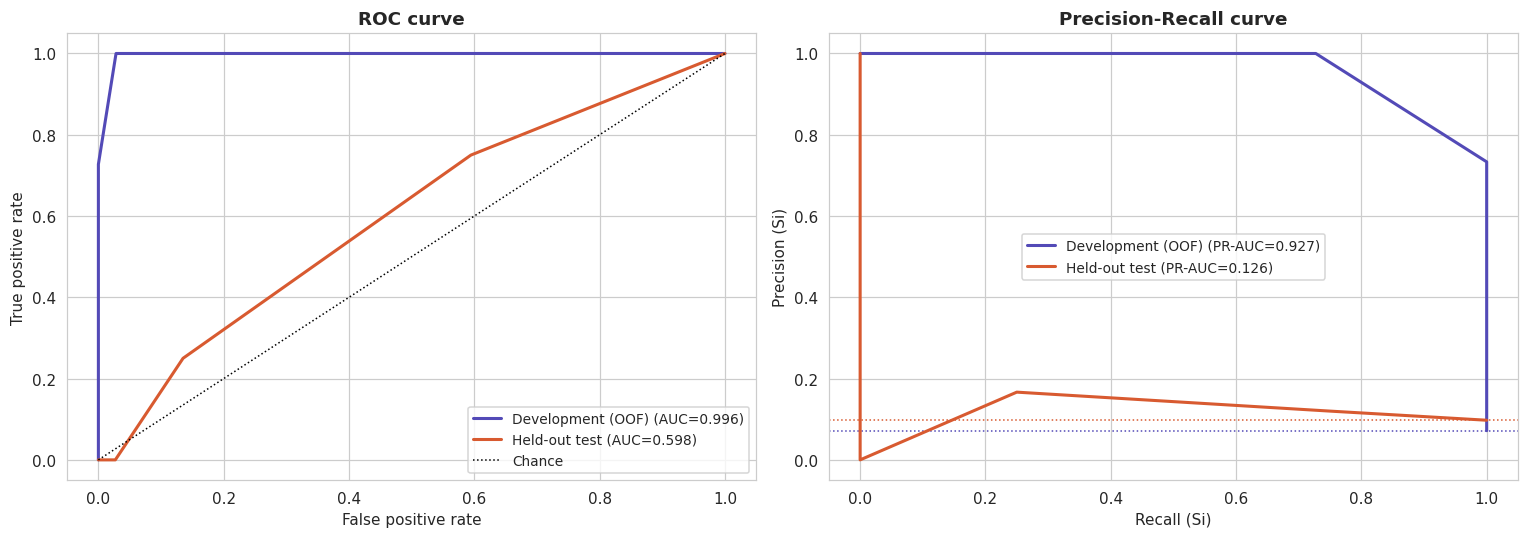

In [21]:
dev_final = candidates[FINAL_NAME][0]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for label, ys, sc, c in [('Development (OOF)', y_dev, dev_final, '#534ab7'),
                         ('Held-out test', y_test, final_test_score, '#d85a30')]:
    fpr, tpr, _ = roc_curve(ys, sc)
    ax[0].plot(fpr, tpr, lw=2, color=c, label=f'{label} (AUC={roc_auc_score(ys, sc):.3f})')
ax[0].plot([0,1],[0,1],'k:',lw=1,label='Chance')
ax[0].set_xlabel('False positive rate'); ax[0].set_ylabel('True positive rate')
ax[0].set_title('ROC curve', fontweight='bold'); ax[0].legend(fontsize=9)
for label, ys, sc, c in [('Development (OOF)', y_dev, dev_final, '#534ab7'),
                         ('Held-out test', y_test, final_test_score, '#d85a30')]:
    pr, rc, _ = precision_recall_curve(ys, sc)
    ax[1].plot(rc, pr, lw=2, color=c, label=f'{label} (PR-AUC={average_precision_score(ys, sc):.3f})')
    ax[1].axhline(ys.mean(), color=c, ls=':', lw=1)
ax[1].set_xlabel('Recall (Si)'); ax[1].set_ylabel('Precision (Si)')
ax[1].set_title('Precision-Recall curve', fontweight='bold'); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig('plot_m5_roc_pr.png', bbox_inches='tight'); plt.show()

### 12.2 Confusion matric and the locked threshold

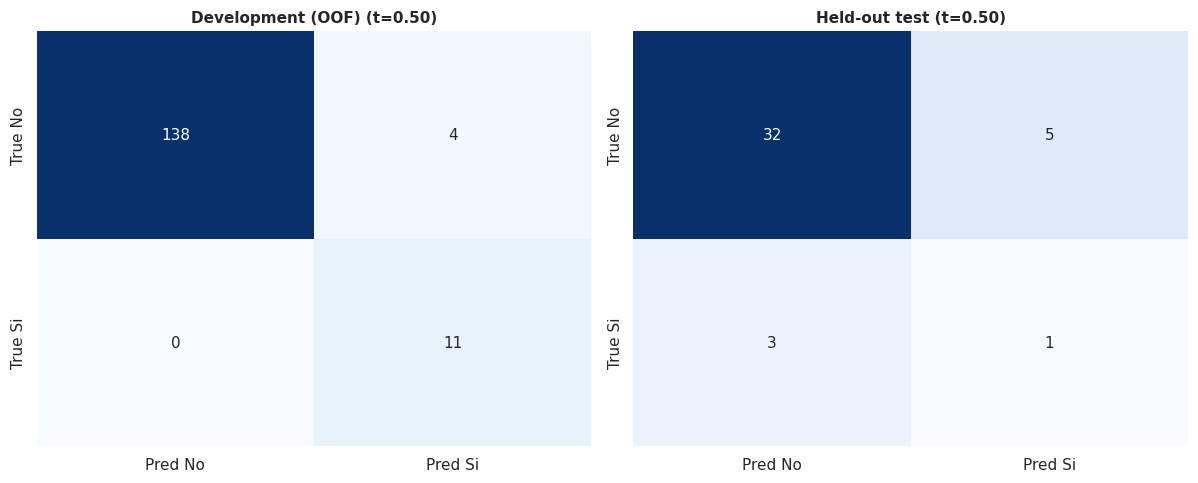

In [16]:
?dev_final = candidates[FINAL_NAME][0]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, (split, ys, pred) in zip(ax, [
        ('Development (OOF)', y_dev, (dev_final >= FINAL_THRESHOLD).astype(int)),
        ('Held-out test', y_test, final_test_pred)]):
    cm = confusion_matrix(ys, pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=a,
                xticklabels=['Pred No','Pred Si'], yticklabels=['True No','True Si'])
    a.set_title(f'{split} (t={FINAL_THRESHOLD:.2f})', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.savefig('plot_m5_confusion.png', bbox_inches='tight'); plt.show()

### 12.3 Threshold sweep

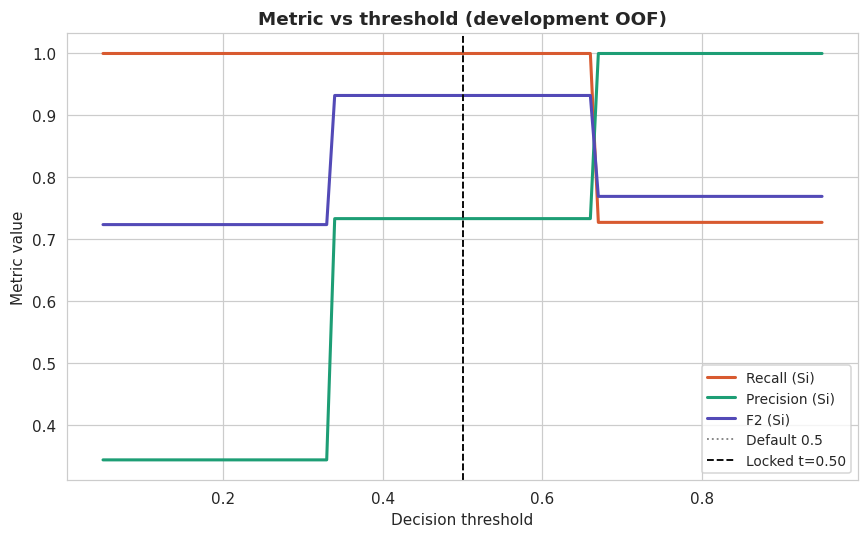

In [22]:
s = sweep_threshold(y_dev, dev_final)
fig, a = plt.subplots(figsize=(8, 5))
a.plot(s['threshold'], s['recall'], label='Recall (Si)', color='#d85a30', lw=2)
a.plot(s['threshold'], s['precision'], label='Precision (Si)', color='#1d9e75', lw=2)
a.plot(s['threshold'], s['f2'], label='F2 (Si)', color='#534ab7', lw=2)
a.axvline(0.5, color='gray', ls=':', lw=1.2, label='Default 0.5')
a.axvline(FINAL_THRESHOLD, color='black', ls='--', lw=1.2, label=f'Locked t={FINAL_THRESHOLD:.2f}')
a.set_xlabel('Decision threshold'); a.set_ylabel('Metric value')
a.set_title('Metric vs threshold (development OOF)', fontweight='bold'); a.legend(fontsize=9)
plt.tight_layout(); plt.savefig('plot_m5_threshold.png', bbox_inches='tight'); plt.show()

### 12.4 Calibration curve

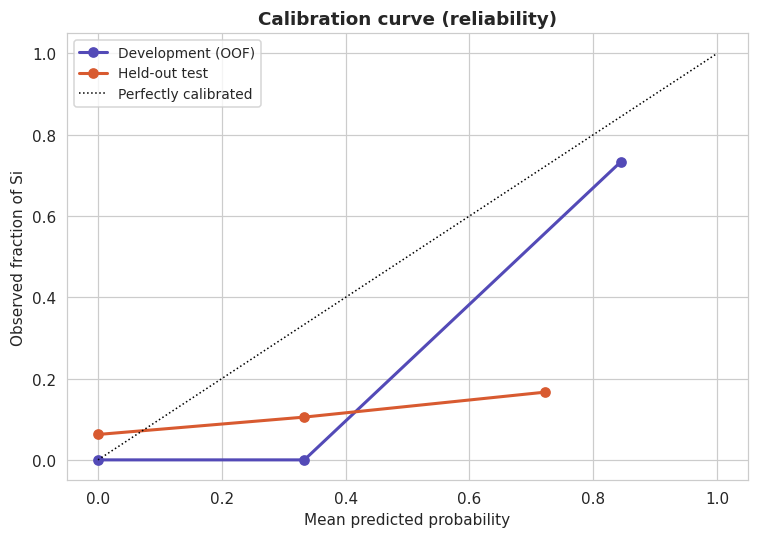

In [23]:
fig, a = plt.subplots(figsize=(7, 5))
for label, ys, sc, c in [('Development (OOF)', y_dev, dev_final, '#534ab7'),
                         ('Held-out test', y_test, final_test_score, '#d85a30')]:
    try:
        fp, mp = calibration_curve(ys, sc, n_bins=5, strategy='quantile')
        a.plot(mp, fp, 'o-', color=c, lw=2, label=label)
    except Exception as e:
        print(f'Calibration skipped for {label}: {e}')
a.plot([0,1],[0,1],'k:',lw=1,label='Perfectly calibrated')
a.set_xlabel('Mean predicted probability'); a.set_ylabel('Observed fraction of Si')
a.set_title('Calibration curve (reliability)', fontweight='bold'); a.legend(fontsize=9)
plt.tight_layout(); plt.savefig('plot_m5_calibration.png', bbox_inches='tight'); plt.show()

### 12.5 Model specific interpretability graphic

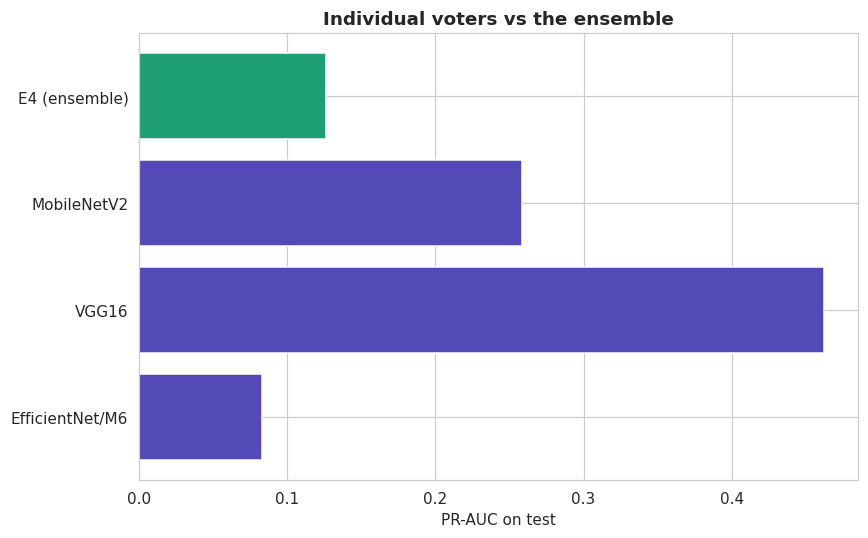

Interpretation: Each bar is the PR-AUC of a voter alone versus the ensemble. If the ensemble beats its best individual voter, the voting is helping; if not, check which network adds noise (the tutor suggested dropping from 4 to 3 models with justification).


In [24]:
fig, a = plt.subplots(figsize=(8, 5)); interp = None
if FINAL_NAME.startswith('E5'):
    names = ['M6 (EfficientNet)','VGG16','MobileNetV2','HCQ+SVM']; coefs = meta_model.coef_[0]
    order = np.argsort(coefs)
    a.barh([names[i] for i in order], coefs[order], color='#1d9e75'); a.axvline(0, color='gray', lw=1)
    a.set_xlabel('Meta-model coefficient (trust weight)')
    a.set_title('Stacking: which model the referee trusts', fontweight='bold')
    interp = ('Positive coefficients indicate the meta-model relies on that base model to predict Si. '
              'This is the interpretability payoff of stacking: it shows, at a glance, which model carries the combined decision.')
elif FINAL_NAME.startswith(('E3','E4')):
    vs = ['EfficientNet/M6','VGG16','MobileNetV2']
    prs = [average_precision_score(y_test, test_score[v]) for v in vs] + [tm['pr_auc']]
    labs = vs + [FINAL_NAME.split(':')[0] + ' (ensemble)']
    a.barh(labs, prs, color=['#534ab7','#534ab7','#534ab7','#1d9e75'])
    a.set_xlabel('PR-AUC on test'); a.set_title('Individual voters vs the ensemble', fontweight='bold')
    interp = ('Each bar is the PR-AUC of a voter alone versus the ensemble. If the ensemble beats '
              'its best individual voter, the voting is helping; if not, check which network adds noise '
              '(the tutor suggested dropping from 4 to 3 models with justification).')
elif FINAL_NAME.startswith(('E1','E2')):
    est = e1_fit if FINAL_NAME.startswith('E1') else e2_fit
    r = permutation_importance(est, X_hcq_test, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, scoring='average_precision')
    top = np.argsort(r.importances_mean)[-20:]
    a.barh([f'HCQ dim {i}' for i in top], r.importances_mean[top], color='#534ab7')
    a.set_xlabel('Permutation importance (drop in PR-AUC)')
    a.set_title('Top-20 HCQuery features of the ensemble', fontweight='bold')
    interp = ('Each bar is how much the test PR-AUC drops when that HCQuery dimension is permuted. A short tail of '
              'dimensions doing almost all the work suggests the model relies on a compact signal.')
else:
    interp = ('Grad-CAM highlights the retinal regions the CNN used to flag toxicity; ideally the '
              'outer parafoveal layers (IS/OS junction, outer nuclear layer), the known site of HCQ damage.')
    try:
        plt.close(fig); m6 = fitted_models['EfficientNet/M6']; fo = {}
        def hook(m,i,o): o.retain_grad(); fo['a'] = o
        h = m6._conv_head.register_forward_hook(hook)
        si = df_test[df_test['label_enc']==1].reset_index(drop=True); n = min(3, len(si))
        if n == 0: raise RuntimeError('no Si in test')
        ev = make_eval_transform(CNN_CFG['EfficientNet/M6']['img'])
        fig, axg = plt.subplots(1, n, figsize=(5*n, 5)); axg = [axg] if n==1 else axg
        m6.eval()
        for j in range(n):
            x,_ = OCTDatasetRGB(si, ev)[j]; x = x.unsqueeze(0).to(DEVICE)
            m6.zero_grad(); m6(x).squeeze().backward()
            act = fo['a']; w = act.grad.mean(dim=(2,3), keepdim=True)
            cam = F.relu((w*act).sum(1))[0].detach().cpu().numpy()
            cam = (cam-cam.min())/(cam.ptp()+1e-8)
            img = Image.open(si.iloc[j]['filepath']).convert('RGB').resize((256,256))
            ci = np.array(Image.fromarray((cam*255).astype('uint8')).resize((256,256)))
            axg[j].imshow(img); axg[j].imshow(ci, cmap='jet', alpha=0.45); axg[j].axis('off')
            axg[j].set_title(f'Si test {j+1}', fontsize=10)
        h.remove(); plt.tight_layout(); plt.savefig('plot_m5_gradcam.png', bbox_inches='tight'); plt.show()
        print('Interpretation:', interp); interp = None
    except Exception as e:
        print(f'Grad-CAM unavailable ({e}); the four diagnostics above are the model report.'); interp = None
if interp is not None:
    plt.tight_layout(); plt.savefig('plot_m5_importance.png', bbox_inches='tight'); plt.show()
    print('Interpretation:', interp)

## Appendix A: Cost of the held-out split

This appendix re-runs the entire model lineup on **all** the data (full-data OOF, all 15 Si cases), reusing the same network configurations and the dev-tuned tree hyperparameters, and compares it against the development-only OOF. The only thing that changes between the two runs is how many toxicity patients are in the evaluation, so the difference measures how much carving out the held-out test set distorts the development estimate. The interpretation is in Section 12.4.

In [17]:
RUN_HELDOUT_COST_EXPERIMENT = True   # set False to skip (saves a second CNN training pass)

if RUN_HELDOUT_COST_EXPERIMENT:
    voters_app = ['EfficientNet/M6', 'VGG16', 'MobileNetV2']
    sgkf_full = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # --- Deep networks: OOF over ALL 194 images (same configs as the main run) ---
    cnn_oof_full = {}
    for name in voters_app:
        print(f'[full-data] Training {name} across all-data folds...')
        oof_f, _ = cnn_oof_scores(name, df, y_all, groups_all, sgkf_full)
        cnn_oof_full[name] = oof_f
        print(f'  {name}: full-data OOF PR-AUC {average_precision_score(y_all, oof_f):.3f}')

    # --- Classical + tree ensembles on full data (reuse the dev-tuned hyperparameters) ---
    oof_svm_full, _ = oof_proba_classical(build_svm, X_hcq_all, y_all, groups_all, sgkf_full)
    oof_e1_full, _  = oof_proba_classical(rf_factory, X_hcq_all, y_all, groups_all, sgkf_full)
    oof_e2_full, _  = oof_proba_classical(gb_factory, X_hcq_all, y_all, groups_all, sgkf_full)

    # --- Heterogeneous ensembles on full data ---
    Vf = np.column_stack([cnn_oof_full[v] for v in voters_app])
    oof_e3_full = Vf.mean(axis=1)
    voter_thr_full = {v: best_f2_threshold(y_all, cnn_oof_full[v]) for v in voters_app}
    oof_e4_full = np.column_stack([(cnn_oof_full[v] >= voter_thr_full[v]).astype(int)
                                   for v in voters_app]).mean(axis=1)
    Mf = np.column_stack([cnn_oof_full['EfficientNet/M6'], cnn_oof_full['VGG16'],
                          cnn_oof_full['MobileNetV2'], oof_svm_full])
    oof_e5_full = cross_val_predict(meta_factory(), Mf, y_all, groups=groups_all,
                                    cv=sgkf_full, method='predict_proba')[:, 1]

    full_oof = {
        'IND EfficientNet/M6': cnn_oof_full['EfficientNet/M6'],
        'IND VGG16': cnn_oof_full['VGG16'],
        'IND MobileNetV2': cnn_oof_full['MobileNetV2'],
        'IND HCQ+SVM': oof_svm_full,
        'E1: Random forest (bagging)': oof_e1_full,
        'E2: Gradient boosting (boosting)': oof_e2_full,
        'E3: Soft voting': oof_e3_full,
        'E4: Hard voting': oof_e4_full,
        'E5: Stacking': oof_e5_full,
    }
    print('\nFull-data OOF computed for all models.')

[full-data] Training EfficientNet/M6 across all-data folds...
  [EfficientNet/M6] fold 0 done
  [EfficientNet/M6] fold 1 done
  [EfficientNet/M6] fold 2 done
  [EfficientNet/M6] fold 3 done
  [EfficientNet/M6] fold 4 done
  EfficientNet/M6: full-data OOF PR-AUC 0.414
[full-data] Training VGG16 across all-data folds...
  [VGG16] fold 0 done
  [VGG16] fold 1 done
  [VGG16] fold 2 done
  [VGG16] fold 3 done
  [VGG16] fold 4 done
  VGG16: full-data OOF PR-AUC 0.248
[full-data] Training MobileNetV2 across all-data folds...
  [MobileNetV2] fold 0 done
  [MobileNetV2] fold 1 done
  [MobileNetV2] fold 2 done
  [MobileNetV2] fold 3 done
  [MobileNetV2] fold 4 done
  MobileNetV2: full-data OOF PR-AUC 0.203

Full-data OOF computed for all models.


In [18]:
if RUN_HELDOUT_COST_EXPERIMENT:
    rows = []
    for name, score_full in full_oof.items():
        pr_f = average_precision_score(y_all, score_full)
        _, lo_f, hi_f = bootstrap_ci(y_all, score_full)
        thr_f = 0.5 if name == 'E4: Hard voting' else best_f2_threshold(y_all, score_full)
        rec_f = recall_score(y_all, (score_full >= thr_f).astype(int), pos_label=1, zero_division=0)
        dev_row = comp_df.loc[name]
        rows.append({
            'model': name,
            'PR-AUC dev-only': dev_row['pr_auc'],
            'PR-AUC full-data': pr_f,
            'delta': pr_f - dev_row['pr_auc'],
            'CIw dev-only': dev_row['ci_hi'] - dev_row['ci_lo'],
            'CIw full-data': hi_f - lo_f,
            'recall dev-only': dev_row['recall_Si'],
            'recall full-data': rec_f,
        })
    cost_df = pd.DataFrame(rows).set_index('model').sort_values('PR-AUC full-data', ascending=False)
    print(f'Si cases in OOF evaluation:  full-data = {int(y_all.sum())}   dev-only = {int(y_dev.sum())}')
    print(f'(carving out the test fold removed {int(y_all.sum()) - int(y_dev.sum())} Si cases from the estimate)\n')
    print('Effect of the held-out split (positive delta = full data scores higher):\n')
    print(cost_df.round(3).to_string())
    print(f'\nMean |delta| PR-AUC across models: {cost_df["delta"].abs().mean():.3f}')
    print(f'Mean bootstrap CI width:  dev-only = {cost_df["CIw dev-only"].mean():.3f}   '
          f'full-data = {cost_df["CIw full-data"].mean():.3f}')

Si cases in OOF evaluation:  full-data = 15   dev-only = 11
(carving out the test fold removed 4 Si cases from the estimate)

Effect of the held-out split (positive delta = full data scores higher):

                                  PR-AUC dev-only  PR-AUC full-data  delta  CIw dev-only  CIw full-data  recall dev-only  recall full-data
model                                                                                                                                     
E4: Hard voting                             0.927             0.516 -0.412         0.177          0.457            1.000             0.733
IND EfficientNet/M6                         0.590             0.414 -0.176         0.538          0.490            0.818             0.600
E3: Soft voting                             0.881             0.309 -0.571         0.249          0.368            1.000             0.667
IND VGG16                                   0.531             0.248 -0.283         0.501          0.183  

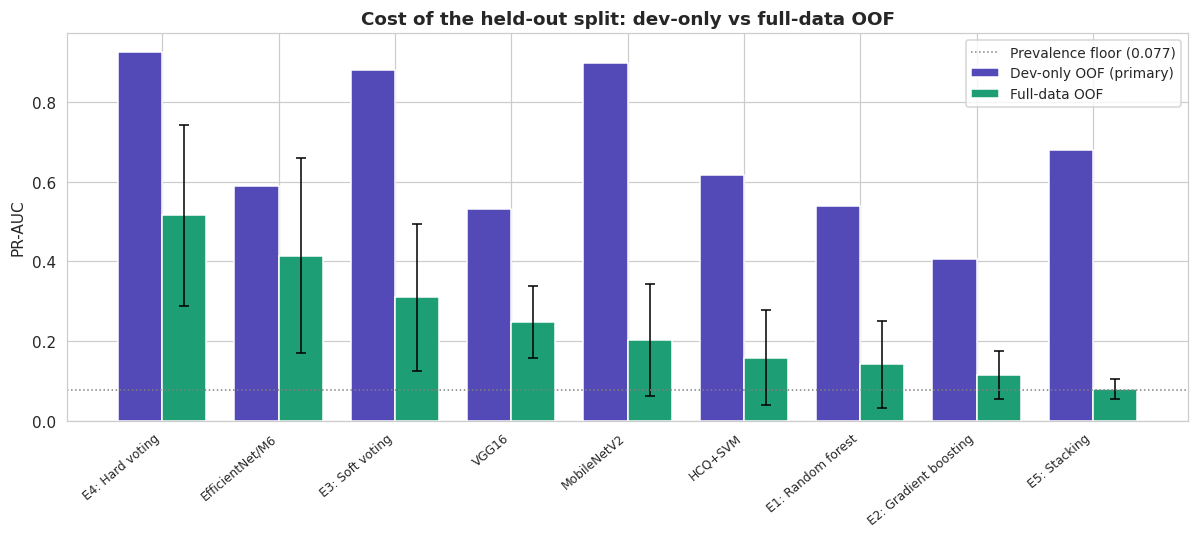

In [19]:
if RUN_HELDOUT_COST_EXPERIMENT:
    models = cost_df.index.tolist()
    short = [m.replace('IND ', '').replace(' (bagging)', '').replace(' (boosting)', '') for m in models]
    x = np.arange(len(models)); w = 0.38
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - w/2, cost_df['PR-AUC dev-only'].values, w, label='Dev-only OOF (primary)', color='#534ab7')
    ax.bar(x + w/2, cost_df['PR-AUC full-data'].values, w, label='Full-data OOF', color='#1d9e75')
    # CI whiskers on the full-data bars
    ax.errorbar(x + w/2, cost_df['PR-AUC full-data'].values,
                yerr=(cost_df['CIw full-data'].values / 2), fmt='none', ecolor='black', capsize=3, lw=1)
    ax.axhline(y_all.mean(), color='gray', ls=':', lw=1, label=f'Prevalence floor ({y_all.mean():.3f})')
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('PR-AUC'); ax.set_title('Cost of the held-out split: dev-only vs full-data OOF', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig('plot_m5_heldout_cost.png', bbox_inches='tight', dpi=110); plt.show()


## Appendix B: Grad-CAM

Grad-CAM overlays show which retinal regions the fine-tuned HCQuery network (M6) used to flag toxicity: warm areas pushed the prediction toward Si. Clinically meaningful attention should fall on the parafoveal outer retinal layers (IS/OS junction, outer nuclear layer), the known site of HCQ damage. The interpretation is in Section 12.5.

Using the M6 model already fitted on the development split.


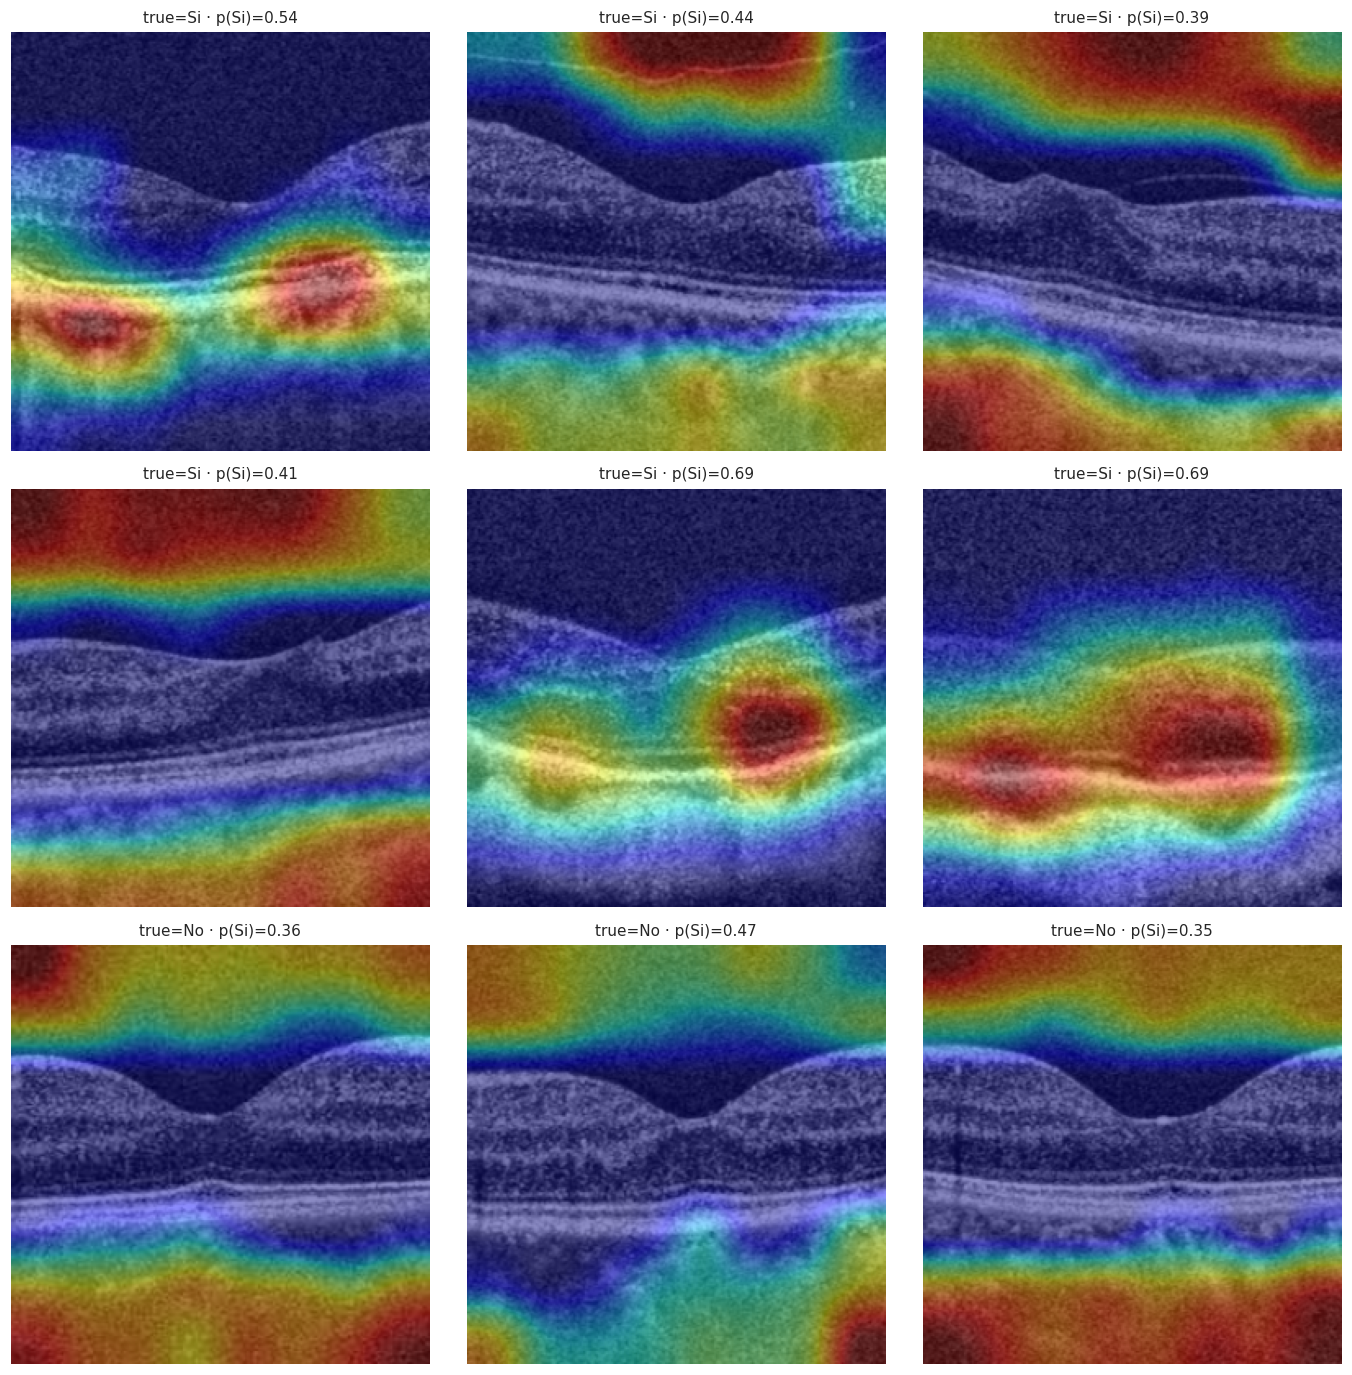

In [20]:
# Appendix B: Grad-CAM

import torch.nn.functional as F

# 1) Use the M6 model already fitted on dev; train one if absent.
if 'fitted_models' in globals() and 'EfficientNet/M6' in fitted_models:
    gc_model = fitted_models['EfficientNet/M6']
    print('Using the M6 model already fitted on the development split.')
else:
    print('No fitted M6 found; training one on dev for Grad-CAM...')
    gc_model, _ = cnn_fit_predict('EfficientNet/M6', df_dev, df_dev.iloc[:1])

gc_model.eval()
IMG   = CNN_CFG['EfficientNet/M6']['img']
gc_tf = make_eval_transform(IMG)

# 2) Grad-CAM for one image tensor -> (heatmap in [0,1], P(Si))
def grad_cam(model, x):
    feats = {}
    def hook(m, i, o):
        o.retain_grad(); feats['act'] = o
    h = model._conv_head.register_forward_hook(hook)
    model.zero_grad()
    logit = model(x).squeeze()
    prob  = torch.sigmoid(logit).item()
    logit.backward()
    act  = feats['act']                              # [1, C, h, w]
    w    = act.grad.mean(dim=(2, 3), keepdim=True)   # channel weights
    cam  = F.relu((w * act).sum(dim=1))[0]           # [h, w]
    cam  = cam.detach().cpu().numpy()
    cam  = (cam - cam.min()) / (np.ptp(cam) + 1e-8)
    h.remove()
    return cam, prob

# 3) Pick images: all/most Si cases + a few No for contrast
N_SI_SHOW, N_NO_SHOW = 6, 3
si_imgs = df[df['label_enc'] == 1].reset_index(drop=True).head(N_SI_SHOW)
no_imgs = (df[df['label_enc'] == 0]
           .sample(n=N_NO_SHOW, random_state=RANDOM_STATE)
           .reset_index(drop=True))
show = pd.concat([si_imgs, no_imgs], ignore_index=True)

# 4) Plot original OCT + Grad-CAM overlay
n, cols = len(show), 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 4.2*rows))
axes = np.array(axes).reshape(-1)
for ax in axes:
    ax.axis('off')
for j in range(n):
    row = show.iloc[j]
    pil = Image.open(row['filepath']).convert('RGB').resize((IMG, IMG))
    x   = gc_tf(pil).unsqueeze(0).to(DEVICE)
    cam, prob = grad_cam(gc_model, x)
    cam_up = np.array(Image.fromarray((cam*255).astype('uint8')).resize((IMG, IMG)))
    true = 'Si' if row['label_enc'] == 1 else 'No'
    axes[j].imshow(pil)
    axes[j].imshow(cam_up, cmap='jet', alpha=0.45)
    axes[j].set_title(f'true={true} · p(Si)={prob:.2f}', fontsize=10)
plt.tight_layout()
plt.savefig('plot_appendixB_gradcam.png', bbox_inches='tight', dpi=110)
plt.show()

## 13. Results and Conclusion

### 13.1 What was built

Five ensemble models covering both required strategies: two homogeneous (`random forest` = bagging and `gradient boosting` = boosting, both on the 1792-d HCQuery features) and three heterogeneous (`soft voting`, `hard voting`, and `stacking` over the deep networks plus the SVM). Following the tutor's recommendation, two additional networks, VGG16 and MobileNetV2, were trained on our data and added to the fine-tuned EfficientNet/M6 (HCQuery) backbone as voters; the two tree ensembles were tuned with Optuna. The primary metric is PR-AUC, and the operating threshold is tuned for F2 (recall-weighted), since the clinical goal is high-sensitivity screening.

### 13.2 Primary results (development OOF)

On the development out-of-fold evaluation, the ranking by PR-AUC was led by hard voting (0.927), MobileNetV2 (0.899), and soft voting (0.881), with stacking (0.680), the SVM (0.617), EfficientNet/M6 (0.590), random forest (0.540), VGG16 (0.531), and gradient boosting (0.406) behind them. Recall was high for the top models, hard voting and soft voting both caught all 11 of 11 development Si images. However, the bootstrap confidence intervals are very wide and heavily overlapping (hard voting is [0.823, 1.000]), so no model is statistically separated from the others. This is the direct consequence of the dataset: the 15 Si images come from only 5 patients, and development contains just 11 Si images from 3 of them.

### 13.3 Final model and held-out test

The recall-first rule selected **hard voting** as the final model (F2 0.932, recall 1.000, PR-AUC 0.927, locked threshold 0.50), because at overlapping CIs the clinical priority is to miss as few toxicity cases as possible. On the patient-disjoint held-out test set (4 Si images from 2 unseen patients), hard voting scored PR-AUC 0.126 and recall 0.250, catching 1 of the 4 cases. This sharp drop from development is expected and informative: with only 3 toxicity patients in development, the cross-validation partly recognizes specific patients rather than the pathology itself, so performance does not transfer cleanly to new patients. The held-out test is too small to be definitive, which is exactly why it is reported as a secondary check, but it flags a real generalization gap.

### 13.4 Appendix A: cost of the held-out split

Re-running the full lineup on all 15 Si cases (full-data OOF) and comparing it to the development-only OOF shows that **every model dropped**, with a mean absolute fall of 0.432 PR-AUC. The development-only numbers were optimistic across the board. The full-data OOF is the most trustworthy estimate available, because it uses all five toxicity patients in rotation (each held out once while the model trains on the other four). On that honest evaluation the selected hard-voting model scores **PR-AUC 0.516 with recall 0.733**, about 6.7x the 0.077 prevalence floor, a real but modest signal. The reshuffle is itself informative: MobileNetV2 was the biggest mirage (0.899 to 0.203), EfficientNet/M6 was the most stable (0.590 to 0.414), and hard voting remained the best model under the harder evaluation (0.516). The average bootstrap CI width also narrowed (0.407 to 0.268), confirming that adding the two held-out patients back stabilizes the estimate. Practically: at five toxicity patients, carving out a held-out test set costs roughly 0.43 PR-AUC of apparent performance, so the development-only headline cannot be reported at face value and the full-data OOF should be the number of record.

### 13.5 Appendix B: Grad-CAM interpretability

The Grad-CAM overlays are consistent with that story. On the cases the model is most confident about, attention is focal and lands on the parafoveal outer retina, the clinically correct site of HCQ toxicity. On lower-confidence Si cases and on the No cases, attention drifts to the dark vitreous band at the top of the image, the noise floor at the bottom, and the image corners, all non-anatomical shortcuts. The model has therefore learned the right feature but relies on it only intermittently, falling back on global image cues when uncertain. This is the visual signature of too few training patients, and it echoes the acquisition-artifact concern from earlier milestones.

### 13.6 Conclusions

The methodology incorporates four safeguards: leakage-free stacking and voting, a patient-disjoint held-out test set, a recall-weighted selection criterion aligned with the clinical objective, and a full-data out-of-fold estimate. The selected model is hard voting, which achieves a PR-AUC of approximately 0.52 and a recall of 0.73 on the full-data OOF evaluation.

The principal limiting factor is the number of toxicity patients (5) rather than the number of images (15). Three patients in the development set are insufficient for the model to learn generalizable features: the development metrics overestimate performance by approximately 0.43 PR-AUC, and the Grad-CAM analysis indicates that the model attends to background regions rather than retinal structures in lower-confidence cases. The primary recommendation to Dr. Rodríguez García is therefore to expand the dataset with additional toxicity patients rather than additional images of the existing patients, whose images are highly correlated (one patient contributes 7 of the 15 Si images). A complementary and lower-cost measure is a more restrictive region-of-interest crop that excludes the vitreous and noise-floor bands, constraining the network to the retinal layers and reducing the background shortcuts observed in Appendix B.

## References

- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *KDD '19*.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825-2830.
- Simonyan, K., & Zisserman, A. (2015). Very deep convolutional networks for large-scale image recognition (VGG16). *ICLR*.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR*.
- Bustamante-Arias, A., et al. (2021). [Sponsor's deep-features + classifier study, verify the exact entry used in M3/M4 before submitting.]
- van Velthoven, M. E. J., et al. (2006). Influence of cataract on optical coherence tomography image quality. *British Journal of Ophthalmology*.